<a href="https://colab.research.google.com/github/harrshat/MachineLearningReferenceDocs/blob/main/K%20Means%20Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from sklearn.datasets import make_blobs

In [4]:
X,y=make_blobs(n_samples=1000, n_features = 2, centers = 3)

In [5]:
X

array([[ 8.10304619, -0.83891471],
       [ 4.05531151,  1.48479698],
       [ 9.00839733,  0.47918373],
       ...,
       [ 9.31027917, -1.50628708],
       [-6.55942222, 10.83050786],
       [-7.7523533 ,  8.71625498]])

In [9]:
set(y)

{np.int64(0), np.int64(1), np.int64(2)}

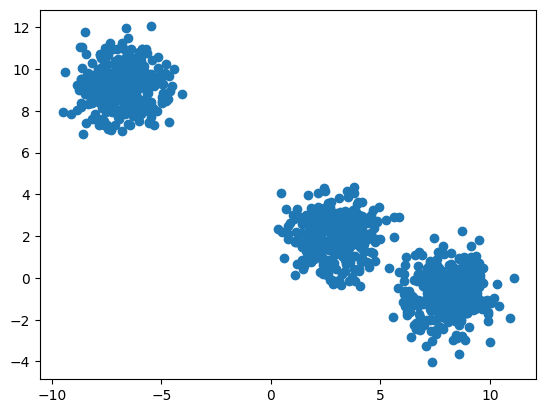

In [13]:
plt.scatter(X[:,0],X[:,1])

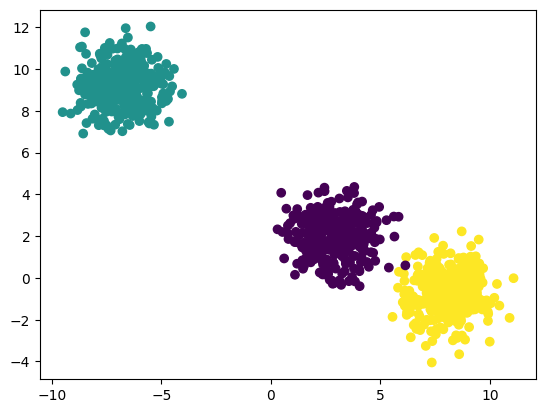

In [14]:
plt.scatter(X[:,0],X[:,1],c=y)

In [16]:
# Standardization - Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
from sklearn.model_selection import train_test_split

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [21]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((700, 2), (700,), (300, 2), (300,))

In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.cluster import KMeans

In [25]:
#Elbow method to determine K value
wcss = []
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)


In [26]:
wcss

[1400.0000000000007,
 177.20027047093342,
 54.703782890254026,
 45.778009842955036,
 43.590265219767566,
 36.56149910460033,
 27.33368379723142,
 25.287261857042054,
 23.354046266053693,
 20.800280457613457]

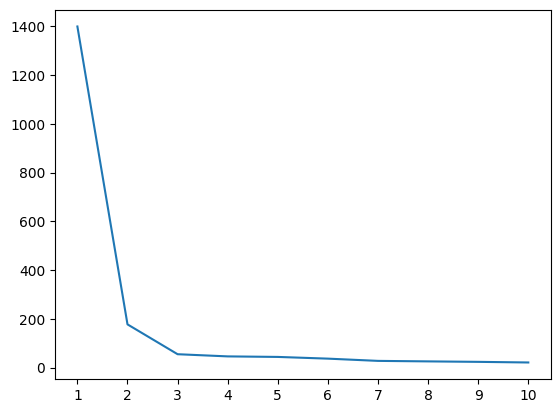

In [36]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.show()
# Inference - Value of 'k' is 3

In [37]:
kmeans=KMeans(n_clusters=3,init='k-means++')
kmeans.fit_predict(X_train_scaled)

array([0, 0, 1, 2, 0, 2, 2, 0, 0, 1, 0, 1, 2, 1, 1, 2, 1, 2, 2, 2, 0, 0,
       1, 1, 2, 1, 2, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 2, 2, 0, 2, 0, 0, 2, 1, 2, 0, 2, 0, 2, 2, 2, 1, 2, 1, 2, 0,
       1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 2, 1, 0, 0, 2, 1, 0, 0, 0, 0, 2, 2,
       1, 1, 0, 1, 2, 1, 2, 1, 1, 0, 2, 0, 1, 0, 1, 1, 0, 1, 2, 0, 2, 2,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 2, 2, 0, 2, 0, 0, 2, 1, 2, 1, 2, 1,
       1, 0, 0, 0, 1, 2, 1, 2, 2, 1, 0, 0, 2, 0, 0, 0, 2, 2, 1, 2, 0, 2,
       0, 1, 1, 2, 2, 0, 2, 2, 2, 0, 2, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 2, 2, 2, 0, 0, 1, 0, 1, 0, 2, 2,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1, 0, 0, 0, 2, 0, 0, 2, 2, 2, 1,
       2, 1, 1, 0, 2, 1, 0, 1, 2, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 2, 2,
       2, 1, 1, 2, 1, 0, 1, 2, 1, 0, 2, 1, 0, 0, 0, 1, 2, 1, 1, 1, 1, 1,
       0, 1, 2, 1, 2, 2, 2, 0, 2, 2, 1, 1, 2, 0, 1, 0, 1, 0, 1, 2, 2, 0,
       2, 2, 2, 1, 1, 0, 1, 2, 0, 0, 2, 2, 1, 0, 0,

In [38]:
y_pred=kmeans.predict(X_test_scaled)

In [39]:
y_pred

array([0, 1, 2, 2, 0, 0, 2, 0, 2, 1, 0, 0, 2, 2, 1, 0, 2, 1, 1, 1, 0, 1,
       2, 0, 2, 1, 2, 0, 0, 1, 0, 2, 0, 1, 1, 2, 0, 1, 1, 2, 1, 2, 1, 0,
       2, 2, 1, 0, 1, 2, 1, 0, 1, 1, 0, 1, 0, 1, 2, 0, 0, 0, 1, 2, 2, 0,
       2, 1, 2, 1, 0, 1, 2, 2, 1, 2, 2, 0, 1, 1, 0, 0, 2, 2, 0, 2, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 2, 1, 0, 2, 1, 0, 1, 0, 0, 2, 1, 0,
       1, 1, 0, 1, 0, 1, 2, 2, 0, 2, 1, 2, 2, 0, 2, 2, 2, 0, 1, 1, 0, 1,
       2, 2, 1, 1, 1, 0, 1, 0, 1, 2, 2, 1, 0, 0, 2, 1, 1, 0, 2, 2, 2, 1,
       0, 0, 1, 2, 2, 1, 1, 1, 0, 2, 2, 2, 0, 1, 0, 2, 0, 0, 0, 1, 0, 2,
       2, 1, 1, 0, 2, 1, 0, 1, 0, 0, 2, 1, 0, 0, 2, 1, 0, 2, 0, 2, 0, 1,
       2, 2, 0, 2, 2, 2, 1, 1, 0, 0, 2, 1, 2, 1, 2, 1, 1, 2, 0, 2, 1, 1,
       0, 2, 1, 1, 0, 0, 2, 2, 1, 1, 1, 1, 0, 0, 1, 1, 0, 2, 0, 2, 2, 1,
       2, 1, 2, 2, 0, 1, 2, 0, 2, 0, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0, 2,
       1, 0, 2, 0, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 0, 2, 1, 2, 2, 2, 0, 2,
       1, 0, 1, 0, 2, 1, 0, 2, 2, 0, 2, 1, 0, 0], d

# Validating K-value
 - Method 1: Knee Locator
 - Method 2: Silhouette Scoring



In [42]:
# Knee Locator
!pip install kneed

In [43]:
from kneed import KneeLocator

In [46]:
kn=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kn.elbow

np.int64(2)